# Explainable AI with CNNs: Grad-CAM on Plant Leaves (PlantVillage)

**Topic:** Explainable AI — Gradient-weighted Class Activation Mapping ([Grad-CAM](https://arxiv.org/abs/1610.02391)) for convolutional image models.

**Dataset:** PlantVillage (subset), loaded with `kagglehub` — `mohitsingh1804/plantvillage`.

> **GitHub (replace before submission):** `https://github.com/YOUR_USERNAME/YOUR_REPO_NAME` — repository must be **public** and this URL must work for markers.

This notebook is split into clear sections (as recommended for readability): **data loading**, **model training**, **predictions**, **evaluation**, and **Grad-CAM visualisation**.


## Environment setup

Install dependencies from the repository `requirements.txt`, then run all cells in order.

**Hardware:** A GPU speeds up training but is not required; reduce `BATCH_SIZE` or `EPOCHS` if memory is limited.

**If plots are blank:** use a kernel where PyTorch is installed (`pip install torch torchvision`), run `%matplotlib inline` (next cell), then **Run all** from the top.

**`No module named 'torch'`:** pick the **same Python** where you ran `pip install` (Kernel / Python Environment), or install PyTorch in the active environment.


In [1]:
# Figures must render inside the notebook (not a separate window)
%matplotlib inline


In [2]:
# --- Imports & global style (colour-aware, readable figures) ---
from __future__ import annotations

import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # Windows: avoid OpenMP crash with PyTorch

import random
from dataclasses import dataclass
from pathlib import Path

import kagglehub
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Accessible, print-friendly defaults (large type, colourblind-aware palettes elsewhere)
sns.set_theme(context="notebook", style="whitegrid")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "image.cmap": "cividis",
})


Device: cpu


# 1. Data loading

We download PlantVillage via KaggleHub, pick a **small set of classes** (faster training, clearer story), resize images, and split into **train / validation / test** (70% / 15% / 15%).

**Where the data comes from:** Kaggle dataset [mohitsingh1804/plantvillage](https://www.kaggle.com/datasets/mohitsingh1804/plantvillage). The call `kagglehub.dataset_download("mohitsingh1804/plantvillage")` saves it under your user cache, e.g. `C:\\Users\\<you>\\.cache\\kagglehub\\datasets\\mohitsingh1804\\plantvillage\\...` — inside that you will see `PlantVillage/train/` and `PlantVillage/val/` with one folder per disease class.


In [3]:
# --- 1. Data loading: configuration ---
@dataclass
class DataConfig:
    dataset_slug: str = "mohitsingh1804/plantvillage"
    img_size: int = 224
    batch_size: int = 16
    num_workers: int = 0  # Windows-friendly
    seed: int = 42
    # Speed/reproducibility: cap images per class when running on CPU.
    # Increase for final results if you have time/GPU.
    max_images_per_class: int | None = 120
    # Pick 3–5 disease / health classes (PlantVillage uses "Genus___Class_name" with three underscores)
    class_names: tuple = (
        "Tomato___Tomato_mosaic_virus",
        "Tomato___healthy",
        "Potato___Early_blight",
        "Potato___healthy",
    )
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15


def resolve_class_roots(base: Path) -> list[Path]:
    # Kaggle `mohitsingh1804/plantvillage` uses PlantVillage/train and PlantVillage/val
    # (only two subfolders — older heuristics that required 3+ siblings failed).
    exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

    def is_class_folder(p: Path) -> bool:
        if not p.is_dir():
            return False
        return any(c.suffix in exts for c in p.iterdir() if c.is_file())

    def child_class_count(p: Path) -> int:
        if not p.is_dir():
            return 0
        return sum(1 for s in p.iterdir() if s.is_dir() and is_class_folder(s))

    plant = next((p for p in base.rglob("PlantVillage") if p.is_dir()), None)
    if plant is not None:
        roots: list[Path] = []
        tr, va = plant / "train", plant / "val"
        if tr.is_dir() and child_class_count(tr) >= 2:
            roots.append(tr)
        if va.is_dir() and child_class_count(va) >= 2:
            roots.append(va)
        if roots:
            return roots

    best: Path | None = None
    best_n = 0
    for path in [base, *base.rglob("*")]:
        if not path.is_dir():
            continue
        n = child_class_count(path)
        if n > best_n:
            best_n = n
            best = path
    if best is None or best_n < 2:
        raise FileNotFoundError(f"Could not find class-labelled image folders under {base}")
    return [best]


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


dcfg = DataConfig()
assert abs(dcfg.train_frac + dcfg.val_frac + dcfg.test_frac - 1.0) < 1e-6
set_seed(dcfg.seed)

print("Downloading dataset (first run may take a while)...")
_download_root = Path(kagglehub.dataset_download(dcfg.dataset_slug))
print("Download root:", _download_root)
DATA_ROOTS = resolve_class_roots(_download_root)
print("Class roots (train/val or single folder):", DATA_ROOTS)

# Optional: list folder names from the first root (for fixing `class_names` spellings).
# print(chr(10).join(sorted(p.name for p in DATA_ROOTS[0].iterdir() if p.is_dir())))


Download root: C:\Users\maree\.cache\kagglehub\datasets\mohitsingh1804\plantvillage\versions\1
Class roots (train/val or single folder): [WindowsPath('C:/Users/maree/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1/PlantVillage/train'), WindowsPath('C:/Users/maree/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1/PlantVillage/val')]


In [4]:
# --- 1. Data loading: collect files & split ---


class ListImageDataset(Dataset):
    def __init__(self, paths: list[Path], labels: list[int], transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


selected = [cn for cn in dcfg.class_names if any((r / cn).is_dir() for r in DATA_ROOTS)]
missing = set(dcfg.class_names) - set(selected)
if missing:
    print("WARNING: missing class folders (check spelling):", sorted(missing))

class_dirs = sorted(selected, key=str.lower)
class_to_idx = {c: i for i, c in enumerate(class_dirs)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
print(f"Using {len(class_dirs)} classes:", class_dirs)

all_paths: list[Path] = []
all_labels: list[int] = []
exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
for cname in class_dirs:
    label = class_to_idx[cname]
    for root in DATA_ROOTS:
        cpath = root / cname
        if not cpath.is_dir():
            continue
        files = sorted([p for p in cpath.iterdir() if p.suffix in exts])

        # Optional cap for faster CPU runs (keeps class balance stable)
        cap = getattr(dcfg, "max_images_per_class", None)
        if cap is not None and len(files) > cap:
            rng = np.random.default_rng(dcfg.seed + label)
            pick = rng.choice(len(files), size=cap, replace=False)
            files = [files[i] for i in sorted(pick.tolist())]

        all_paths.extend(files)
        all_labels.extend([label] * len(files))

print("Total images:", len(all_paths))

indices = np.arange(len(all_paths))
strat_labels = np.array(all_labels)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=(1.0 - dcfg.train_frac),
    stratify=strat_labels,
    random_state=dcfg.seed,
)
temp_labels = strat_labels[temp_idx]
rel_test = dcfg.test_frac / (dcfg.val_frac + dcfg.test_frac)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=rel_test,
    stratify=temp_labels,
    random_state=dcfg.seed,
)

print("Train / val / test sizes:", len(train_idx), len(val_idx), len(test_idx))

imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.Resize((dcfg.img_size, dcfg.img_size), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15, interpolation=InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    imagenet_norm,
])
eval_tf = transforms.Compose([
    transforms.Resize((dcfg.img_size, dcfg.img_size), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    imagenet_norm,
])

train_ds = ListImageDataset([all_paths[i] for i in train_idx], [all_labels[i] for i in train_idx], train_tf)
val_ds = ListImageDataset([all_paths[i] for i in val_idx], [all_labels[i] for i in val_idx], eval_tf)
test_ds = ListImageDataset([all_paths[i] for i in test_idx], [all_labels[i] for i in test_idx], eval_tf)

train_dl = DataLoader(train_ds, batch_size=dcfg.batch_size, shuffle=True, num_workers=dcfg.num_workers, pin_memory=(DEVICE.type == "cuda"))
val_dl = DataLoader(val_ds, batch_size=dcfg.batch_size, shuffle=False, num_workers=dcfg.num_workers, pin_memory=(DEVICE.type == "cuda"))
test_dl = DataLoader(test_ds, batch_size=dcfg.batch_size, shuffle=False, num_workers=dcfg.num_workers, pin_memory=(DEVICE.type == "cuda"))


Using 4 classes: ['Potato___Early_blight', 'Potato___healthy', 'Tomato___healthy', 'Tomato___Tomato_mosaic_virus']
Total images: 3116
Train / val / test sizes: 2181 467 468


# Story Figures (for non-technical readers)

These figures are designed like a simple visual “story”:
1. What the dataset looks like (sample photos + class names)
2. How the data is split (train/val/test)
3. How image preprocessing changes a photo for training
4. Later: what the model predicts and where Grad-CAM says it looked


Saved figure: C:\Users\maree\Desktop\Herts\projects\individual project\outputs\00_story_dataset_gallery.png


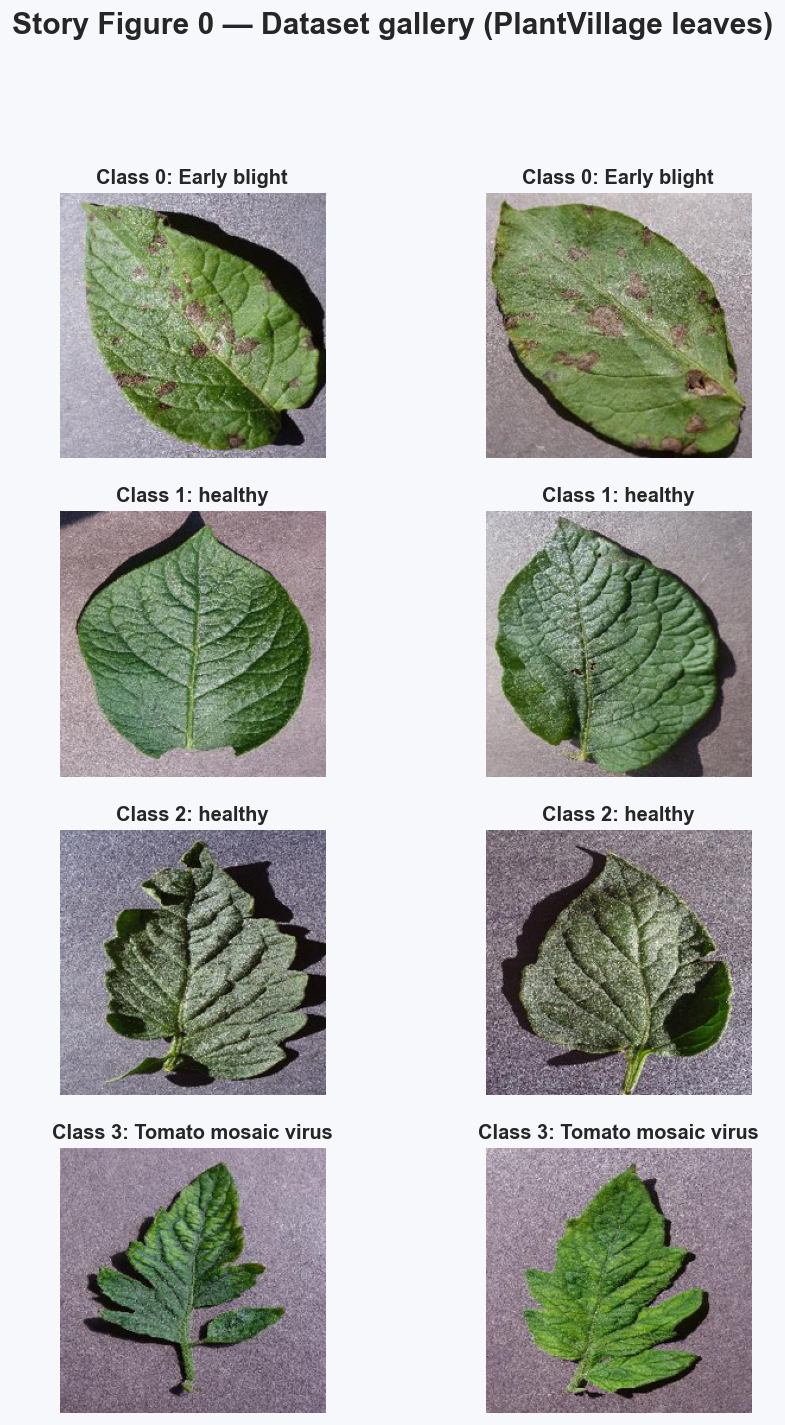

NameError: name 'num_classes' is not defined

In [ ]:
# --- Story Figure helpers ---
# This cell is purely for creating exportable figures for your final web page.

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Robust: derive num_classes here (don’t assume earlier cells defined it)
num_classes = len(class_dirs) if "class_dirs" in globals() else len(idx_to_class)

def style_story_axes(ax):
    # Clean, readable axes for non-technical readers
    ax.set_facecolor("#ffffff")
    for spine in ax.spines.values():
        spine.set_color("#D1D5DB")
        spine.set_linewidth(1.1)

    ax.grid(True, axis="y", color="#E5E7EB", linewidth=0.9)
    ax.tick_params(
        left=True,
        bottom=True,
        labelleft=True,
        labelbottom=True,
        labelsize=10,
        colors="#111827",
    )

def export_fig(fig, filename):
    # Keep existing name so later code doesn't need changing
    out_path = FIG_DIR / filename
    fig.savefig(out_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    print("Saved figure:", out_path.resolve())
    plt.show()

def friendly_label(i: int) -> str:
    return idx_to_class[i].split("___")[-1].replace("_", " ")

# --- Story Figure 0: Dataset gallery (2 samples per class) ---
samples_per_class = 2
chosen = {}
for p, lab in zip(train_ds.paths, train_ds.labels):
    chosen.setdefault(int(lab), []).append(p)
    if len(chosen[int(lab)]) >= samples_per_class:
        continue

rows = len(class_dirs)
cols = samples_per_class
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.2, rows * 3.3))
fig.patch.set_facecolor("#f7f8fb")

if rows == 1:
    axes = np.array([axes])

for r in range(rows):
    class_idx = r
    for c in range(cols):
        ax = axes[r, c]
        style_story_axes(ax)
        img_path = chosen.get(class_idx, [None] * cols)[c]
        if img_path is None:
            ax.axis("off")
            continue
        pil = Image.open(img_path).convert("RGB").resize((dcfg.img_size, dcfg.img_size))
        ax.imshow(pil)
        ax.set_title(
            f"Class {class_idx}: {friendly_label(class_idx)}",
            fontsize=12,
            fontweight="bold",
        )
        ax.axis("off")

fig.suptitle("Story Figure 0 — Dataset gallery (PlantVillage leaves)", fontsize=18, y=0.995, fontweight="bold")
export_fig(fig, "00_story_dataset_gallery.png")

# --- Story Figure 1: Split sizes (train/val/test) ---
train_counts = np.bincount(np.array(train_ds.labels), minlength=num_classes)
val_counts = np.bincount(np.array(val_ds.labels), minlength=num_classes)
test_counts = np.bincount(np.array(test_ds.labels), minlength=num_classes)

labels = [friendly_label(i) for i in range(num_classes)]
x = np.arange(num_classes)
w = 0.28

fig, ax = plt.subplots(figsize=(10.8, 5.8))
fig.patch.set_facecolor("#f7f8fb")

ax.bar(x - w, train_counts, width=w, color="#0173B2", label="Train")
ax.bar(x, val_counts, width=w, color="#DE8F05", label="Validation")
ax.bar(x + w, test_counts, width=w, color="#029B77", label="Test")

style_story_axes(ax)
ax.set_title("Story Figure 1 — How data is split", fontsize=16, fontweight="bold")
ax.set_xlabel("Disease class", fontsize=12)
ax.set_ylabel("Number of images", fontsize=12)

# Show clear numeric scale for non-technical readers
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=10)
ax.legend(frameon=True)

export_fig(fig, "01_story_split_distribution.png")

# --- Story Figure 2: Resize + augmentation examples (same image, different transforms) ---
example_path = train_ds.paths[0]
pil0 = Image.open(example_path).convert("RGB")
pil_resized = pil0.resize((dcfg.img_size, dcfg.img_size))

def denormalize(x_t):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x_t.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x_t.device).view(3, 1, 1)
    x = x_t * std + mean
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).detach().cpu().numpy()

aug1 = denormalize(train_tf(pil0))
aug2 = denormalize(train_tf(pil0))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
fig.patch.set_facecolor("#f7f8fb")
for ax in axes:
    style_story_axes(ax)
    ax.axis("off")

axes[0].imshow(pil_resized)
axes[0].set_title("Story Figure 2A — Original resized", fontsize=13, fontweight="bold")

axes[1].imshow(aug1)
axes[1].set_title("Story Figure 2B — Augmented view #1", fontsize=13, fontweight="bold")

axes[2].imshow(aug2)
axes[2].set_title("Story Figure 2C — Augmented view #2", fontsize=13, fontweight="bold")

fig.suptitle("Story Figure 2 — Training uses variations of the same photo", fontsize=18, y=0.995, fontweight="bold")
export_fig(fig, "02_story_resize_and_augmentation.png")


# 2. Model training

We use **transfer learning**: ImageNet-pretrained **ResNet-18**, with the final layer replaced for our number of classes. Only the final layer is trained first (fast), then a short fine-tuning phase can unlock a bit more accuracy.


In [ ]:
# --- 2. Model training: build model & optimisation ---


def build_model(num_classes: int) -> nn.Module:
    # Demo reliability: use random weights (avoids slow/fragile ImageNet checkpoint downloads).
    m = models.resnet18(weights=None)
    in_f = m.fc.in_features
    m.fc = nn.Linear(in_f, num_classes)
    return m


@dataclass
class TrainConfig:
    lr_head: float = 3e-3
    lr_finetune: float = 1e-4
    # For nicer training curves in figures, use a few epochs.
    # This is still fast because we cap images per class.
    epochs_phase1: int = 2
    epochs_phase2: int = 0
    weight_decay: float = 1e-4


tcfg = TrainConfig()
num_classes = len(class_dirs)
model = build_model(num_classes).to(DEVICE)

# Phase 1: train classifier head only
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=tcfg.lr_head, weight_decay=tcfg.weight_decay)


def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    cm_ctx = torch.enable_grad() if train else torch.no_grad()
    with cm_ctx:
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            if train:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += xb.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, tcfg.epochs_phase1 + 1):
    tr_loss, tr_acc = run_epoch(model, train_dl, train=True)
    va_loss, va_acc = run_epoch(model, val_dl, train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    print(f"[Phase1] Epoch {epoch}/{tcfg.epochs_phase1}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}")

# Phase 2: fine-tune last block + head
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=tcfg.lr_finetune,
    weight_decay=tcfg.weight_decay,
)

for epoch in range(1, tcfg.epochs_phase2 + 1):
    tr_loss, tr_acc = run_epoch(model, train_dl, train=True)
    va_loss, va_acc = run_epoch(model, val_dl, train=False)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    print(f"[Phase2] Epoch {epoch}/{tcfg.epochs_phase2}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  train_acc={tr_acc:.3f}  val_acc={va_acc:.3f}")


In [ ]:
# --- 2b. Training curves (story-first, non-technical) ---

# Design goals:
# - readable at a glance (big text, clear trend cues)
# - works for 1 epoch *and* many epochs
# - export-ready for your webpage

n_epochs = len(history["train_loss"])
epochs = np.arange(1, n_epochs + 1)

train_loss = np.asarray(history["train_loss"], dtype=float)
val_loss = np.asarray(history["val_loss"], dtype=float)
train_acc = np.asarray(history["train_acc"], dtype=float) * 100
val_acc = np.asarray(history["val_acc"], dtype=float) * 100

fig, ax = plt.subplots(1, 2, figsize=(12.6, 4.6))
fig.patch.set_facecolor("#F7F8FB")

c_train = "#1D4ED8"   # blue
c_val = "#F59E0B"     # amber

marker = "o" if n_epochs <= 6 else None

# Panel A: loss
ax[0].set_facecolor("#FFFFFF")
ax[0].plot(epochs, train_loss, color=c_train, linewidth=2.6, marker=marker, label="Train")
ax[0].plot(epochs, val_loss, color=c_val, linewidth=2.6, marker=marker, label="Validation")
ax[0].fill_between(epochs, train_loss, val_loss, color="#93C5FD", alpha=0.18, linewidth=0)
ax[0].set_title("Learning signal (loss)", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Training round (epoch)")
ax[0].set_ylabel("Loss (lower is better)")
ax[0].grid(True, axis="y", color="#E5E7EB")
ax[0].legend(frameon=True)

# Panel B: accuracy
ax[1].set_facecolor("#FFFFFF")
ax[1].plot(epochs, train_acc, color=c_train, linewidth=2.6, marker=marker, label="Train")
ax[1].plot(epochs, val_acc, color=c_val, linewidth=2.6, marker=marker, label="Validation")
ax[1].fill_between(epochs, train_acc, val_acc, color="#FCD34D", alpha=0.16, linewidth=0)
ax[1].set_title("How often it’s right (accuracy)", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Training round (epoch)")
ax[1].set_ylabel("Accuracy % (higher is better)")
ax[1].set_ylim(0, 100)
ax[1].grid(True, axis="y", color="#E5E7EB")
ax[1].legend(frameon=True)

# Non-technical callouts (trend summaries)
if n_epochs >= 2:
    ax[0].annotate(
        "Goal: loss should go down",
        xy=(epochs[-1], float(train_loss[-1])),
        xytext=(epochs[0], float(train_loss[0]) + (train_loss.max() - train_loss.min()) * 0.65),
        arrowprops=dict(arrowstyle="->", color="#111827", lw=1.2),
        fontsize=11,
        color="#111827",
    )
    ax[1].annotate(
        "Goal: accuracy should go up",
        xy=(epochs[-1], float(train_acc[-1])),
        xytext=(epochs[0], max(5.0, float(train_acc[0]) + 12.0)),
        arrowprops=dict(arrowstyle="->", color="#111827", lw=1.2),
        fontsize=11,
        color="#111827",
    )
else:
    # Single-epoch: make it obvious this is one checkpoint
    for a in ax:
        a.set_xlim(0.5, 1.5)
        a.set_xticks([1])
    ax[1].text(0.02, 0.06, "Only 1 epoch run → points only", transform=ax[1].transAxes, fontsize=10, color="#374151")

plt.suptitle(
    "Training progress: are we getting better?",
    fontsize=18,
    fontweight="bold",
    y=1.04,
)
fig.text(
    0.5,
    -0.02,
    "Train = learning on known images • Validation = performance on unseen images (better indicator of real-world behavior)",
    ha="center",
    fontsize=11,
    color="#374151",
)

plt.tight_layout()

Path("figures").mkdir(exist_ok=True)
plt.savefig(Path("figures") / "03_training_curves.png", bbox_inches="tight", dpi=180)
plt.show()


# 3. Predictions

We run the trained model on the **test split** and collect predicted labels for evaluation and Grad-CAM.


In [ ]:
# --- 3. Predictions: run inference on test set ---

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)


y_true, y_pred = predict_loader(model, test_dl)

readable_labels = [c.split("___")[-1].replace("_", " ") for c in [idx_to_class[i] for i in range(num_classes)]]
print("Friendly class names for plots:", readable_labels)


# 4. Evaluation

We report **accuracy**, a **confusion matrix**, and a short **classification report**. In your tutorial, interpret: which classes are easiest, where the model confuses two diseases, and what that means for trust / field use.


In [ ]:
# --- 4. Evaluation: metrics & confusion matrix ---

acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc * 100:.2f}%")
print(classification_report(y_true, y_pred, target_names=readable_labels, digits=3))

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(7.2, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Count of predictions"},
    xticklabels=readable_labels,
    yticklabels=readable_labels,
    linewidths=0.5,
    linecolor="#E0E0E0",
    ax=ax,
)
ax.set_xlabel("Predicted label (what the model guessed)")
ax.set_ylabel("True label (what the photo really was)")
ax.set_title("Confusion matrix: counts on the diagonal are correct predictions")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

Path("figures").mkdir(exist_ok=True)
plt.savefig(Path("figures") / "04_confusion_matrix.png", bbox_inches="tight", dpi=180)

plt.show()


# 5. Grad-CAM: *where* does the model look?

**Idea (intuitive):** Grad-CAM builds a coarse heatmap over the image by combining (a) which pixels strongly pushed the **predicted class score** up and (b) which shallow patterns were present there. Brighter regions are places that **most influenced** that prediction — not necessarily “disease” in a biological sense, but **evidence the network used**.

We visualise: **original leaf**, **heatmap alone**, and **overlay** (heatmap on photo), using a perceptually uniform colormap (`inferno`) so intensity reads clearly even in greyscale print.

We show **three teaching cases**:
1. A **correct** prediction — heatmap should line up with plausible diseased tissue.
2. A **mistake** — heatmap often reveals **misleading** focus (useful for debugging).
3. **Healthy vs diseased** — compare attention patterns side by side.


In [ ]:
# --- 5. Grad-CAM implementation (educational, self-contained) ---


class GradCAM:
    # Grad-CAM on one conv layer's feature maps (before global average pooling).

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self._acts: torch.Tensor | None = None
        self._grads: torch.Tensor | None = None

        def fwd_hook(_m, _inp, out):
            self._acts = out.detach()

        def full_bwd_hook(_m, _gi, go):
            self._grads = go[0].detach()

        self._fwd_handle = target_layer.register_forward_hook(fwd_hook)
        self._bwd_handle = target_layer.register_full_backward_hook(full_bwd_hook)

    def close(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()

    def generate(self, x: torch.Tensor, target_class: int | None = None) -> np.ndarray:
        # x: (1,3,H,W) normalised like training. Returns HxW heatmap in [0,1].
        self.model.eval()
        x = x.clone().detach().to(DEVICE).requires_grad_(True)
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())
        score = logits[0, target_class]
        score.backward()

        acts = self._acts
        grads = self._grads
        if acts is None or grads is None:
            raise RuntimeError("Hooks did not capture activations/gradients")

        weights = grads.mean(dim=(2, 3), keepdim=True)  # global average pooling of gradients
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=False)
        cam = cam[0, 0]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy()


def denormalize_tensor(img_tensor: torch.Tensor) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(3, 1, 1)
    x = img_tensor * std + mean
    x = x.clamp(0.0, 1.0)
    return x.permute(1, 2, 0).detach().cpu().numpy()


def overlay_heatmap(rgb01: np.ndarray, heatmap01: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    cmap = mpl.colormaps["inferno"]
    heat_rgba = cmap(np.clip(heatmap01, 0, 1))
    heat_rgb = heat_rgba[:, :, :3]
    return np.clip((1 - alpha) * rgb01 + alpha * heat_rgb, 0, 1)


def pretty_gradcam_panel(
    model,
    img_path: Path,
    true_label: int,
    title_note: str = "",
    save_as: str | None = None,
):
    raw = Image.open(img_path).convert("RGB")
    x = eval_tf(raw).unsqueeze(0).to(DEVICE)

    target_layer = model.layer4[-1].conv2
    gc = GradCAM(model, target_layer)
    try:
        pred_logits = model(x)
        pred_class = int(pred_logits.argmax(dim=1).item())
        hm = gc.generate(x, target_class=pred_class)
    finally:
        gc.close()

    rgb = denormalize_tensor(x[0])
    overlay = overlay_heatmap(rgb, hm, alpha=0.48)

    def friendly(i: int) -> str:
        return idx_to_class[i].split("___")[-1].replace("_", " ")

    corr = pred_class == true_label
    tag = "Correct prediction" if corr else "Wrong prediction"
    subtitle = f"True: {friendly(true_label)}   |   Model: {friendly(pred_class)}\n{tag}"
    if title_note:
        subtitle = title_note + "\n" + subtitle

    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

    axes[0].imshow(raw.resize((dcfg.img_size, dcfg.img_size)))
    axes[0].set_title("Original photo", fontsize=12)
    axes[0].axis("off")

    im = axes[1].imshow(hm, cmap="inferno", vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM heatmap\n(brighter = stronger influence)", fontsize=12)
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Influence")

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay for non-experts\n(yellow = where the model looked)", fontsize=12)
    axes[2].axis("off")

    fig.text(0.5, -0.02, subtitle, ha="center", fontsize=12)
    plt.suptitle("Explainable AI snapshot: what evidence did the network use?", fontsize=15, y=1.05)
    plt.tight_layout()

    if save_as is not None:
        Path("figures").mkdir(exist_ok=True)
        out = Path("figures") / save_as
        plt.savefig(out, bbox_inches="tight", dpi=180)
        print("Saved:", out.resolve())

    plt.show()


# Helpers to pick interesting examples from test split (order matches test_ds iteration)
test_paths = list(test_ds.paths)
test_labels = list(test_ds.labels)

model.eval()
ys_list, ps_list = [], []
with torch.no_grad():
    for i in range(len(test_ds)):
        xb, yb = test_ds[i]
        logits = model(xb.unsqueeze(0).to(DEVICE))
        ps_list.append(int(logits.argmax(dim=1).item()))
        ys_list.append(int(yb))

correct_idx = next((i for i in range(len(ys_list)) if ys_list[i] == ps_list[i]), 0)
wrong_idx = next((i for i in range(len(ys_list)) if ys_list[i] != ps_list[i]), None)

print("Example indices — correct:", correct_idx, "wrong:", wrong_idx)


In [ ]:
# --- 5b. Case 1: correct prediction ---

pretty_gradcam_panel(
    model,
    Path(test_paths[correct_idx]),
    test_labels[correct_idx],
    title_note="Case 1 — model is right",
    save_as="05_gradcam_case1_correct.png",
)


In [ ]:
# --- 5c. Case 2: wrong prediction (if any) ---

if wrong_idx is None:
    print("No errors on this test split — try more classes/epochs/seed, or show a validation mistake instead.")
else:
    pretty_gradcam_panel(
        model,
        Path(test_paths[wrong_idx]),
        test_labels[wrong_idx],
        title_note="Case 2 — model is wrong (compare heatmap to true disease)",
        save_as="06_gradcam_case2_wrong.png",
    )


In [ ]:
# --- 5d. Case 3: healthy vs diseased (side-by-side overlays) ---

def pick_first_index(label_idx: int) -> int | None:
    for i, y in enumerate(test_labels):
        if y == label_idx:
            return i
    return None


# Choose 'healthy' vs a disease if both exist in selected classes
healthy_names = [i for i, c in enumerate(class_dirs) if "healthy" in c.lower()]
disease_names = [i for i, c in enumerate(class_dirs) if "healthy" not in c.lower()]

hi = healthy_names[0] if healthy_names else None
di = disease_names[0] if disease_names else None

if hi is None or di is None:
    print("Need at least one healthy and one disease class in selection for this demo.")
else:
    i_h = pick_first_index(hi)
    i_d = pick_first_index(di)

    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))

    for row, (idx, name) in enumerate([(i_h, "Healthy example"), (i_d, "Diseased example")]):
        pth = test_paths[idx]
        y = test_labels[idx]
        raw = Image.open(pth).convert("RGB")
        x = eval_tf(raw).unsqueeze(0).to(DEVICE)

        target_layer = model.layer4[-1].conv2
        gc = GradCAM(model, target_layer)
        try:
            logits = model(x)
            pred = int(logits.argmax(dim=1).item())
            hm = gc.generate(x, target_class=pred)
        finally:
            gc.close()

        rgb = denormalize_tensor(x[0])
        overlay = overlay_heatmap(rgb, hm, alpha=0.48)

        axes[row, 0].imshow(raw.resize((dcfg.img_size, dcfg.img_size)))
        axes[row, 0].set_title(f"{name}: original")
        axes[row, 0].axis("off")

        im = axes[row, 1].imshow(hm, cmap="inferno", vmin=0, vmax=1)
        axes[row, 1].set_title("Heatmap (influence)")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title("Overlay")

        friendly = lambda j: idx_to_class[j].split("___")[-1].replace("_", " ")
        fig.text(0.5, 0.93 - row * 0.46, f"True: {friendly(y)}   |   Predicted: {friendly(pred)}", ha="center", fontsize=12)

    plt.suptitle("Case 3 — Attention differs between healthy leaves and diseased leaves", fontsize=15, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    Path("figures").mkdir(exist_ok=True)
    plt.savefig(Path("figures") / "07_gradcam_case3_healthy_vs_diseased.png", bbox_inches="tight", dpi=180)

    plt.show()


## References (starter list — expand in your PDF / web page)

1. Selvaraju, R. R., et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization.* International Journal of Computer Vision.
2. Hughes, D. P., & Salathé, M. (2015). *An open access repository of images on plant health to enable the development of mobile disease diagnostics.* arXiv:1511.08060 (PlantVillage).
3. PyTorch Vision ResNet pretrained weights documentation: [https://pytorch.org/vision/stable/models.html](https://pytorch.org/vision/stable/models.html)

Add blogs or courses you used, and format references in your department’s required style.


## Ethics note (for your written tutorial)

Visual explanations can **look convincing** even when the model is **biased** (background texture, watermark, lighting). Grad-CAM shows *correlation-based evidence the network used*, not causal proof of disease. Mention limits of explainability tools and responsible deployment (e.g. expert confirmation in the field).
